# Homework #3: Data Cleaning
*DSE 511 – Fall 2025*

This notebook handles the data acquisition and cleaning portion of the assignment. Its purpose is to take the raw, messy dataset and produce a clean, well-structured file for each meteorological station, ready for exploratory data analysis (EDA).

**Key Cleaning Steps:**
1.  **Dynamic Data Loading:** Uses a file selector to avoid hardcoded paths.
2.  **Column Renaming:** Renames the cryptic `PRCP` column to be more descriptive.
3.  **Explicit Assumption Handling:** Creates two precipitation columns:
    *   `precipitation_original`: Keeps missing values as `NaN` to preserve the original state.
    *   `precipitation_zero_rain_assumption`: Fills missing values with `0`, based on the assumption that a missing record means no rain fell.
4.  **Data Structuring:** Ensures each station has a continuous daily timeline and fills in metadata (lat, long, elevation) based on the justifiable assumption that these values are constant for a given station.
5.  **Exporting:** Saves the cleaned data for each station into a separate CSV file in the `data/` directory.

In [1]:
import pandas as pd
import tkinter as tk
from tkinter import filedialog
import os

import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple
import numpy as np

from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

# This setup is to make the Tkinter file dialog work smoothly in a notebook
root = tk.Tk()
root.withdraw() # Hide the main window

<StateSpec object: ''>

## 1. Load Raw Data
Instead of a hard-coded path, the cell below will open a file selection dialog.

**Instructions:** Run the cell, and in the pop-up window, navigate to and select the `Raw_Data.xlsx` file. The path to the file will be stored and used to load the data into pandas.

Citation: How to use tkinter to select a file https://stackoverflow.com/questions/16429716/opening-file-tkinter

In [2]:
# Open a file dialog to select the dataset
file_path = filedialog.askopenfilename()
if file_path:
    print(f"File selected: {file_path}")
    try:
        if file_path.endswith(('.csv', '.tsv')):
            # Handle CSV/TSV files
            sep = ',' if file_path.endswith('.csv') else '\t'
            df = pd.read_csv(file_path, sep=sep)
        elif file_path.endswith(('.xlsx', '.xls')):
            # Handle Excel files
            df = pd.read_excel(file_path, sheet_name='Sheet1')
        else:
            raise ValueError("Unsupported file format. Please use CSV, TSV, or Excel files.")

        print("Successfully loaded the dataset.")
        if 'DATE' in df.columns:
            df['DATE'] = pd.to_datetime(df['DATE'])  # Ensure DATE column is datetime
    except Exception as e:
        print(f"Error loading file: {e}")
else:
    print("No file selected. Please run the cell again and choose a file.")

2025-09-15 13:59:30.452 python[23112:344635] The class 'NSOpenPanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


File selected: /Users/zr4/Desktop/work_in_progress/DSE homework/Raw data.csv
Successfully loaded the dataset.


## 2. Initial Data Transformation
Here, we perform two key steps:
1.  Rename the `PRCP` column for clarity.
2.  Create a separate column to house our "zero rain" assumption, preserving the original data.

Citation: How to check if a variable exists in python https://stackoverflow.com/questions/843277/how-do-i-check-if-a-variable-exists

In [3]:
if 'df' in locals():
    # 1. Change the name of the PRCP column
    df.rename(columns={'PRCP': 'precipitation_original'}, inplace=True)
    
    # 2. Copy the precipitation column for our assumption
    df['precipitation_zero_rain_assumption'] = df['precipitation_original']
    
    # 3. In the copied column, replace missing values with zero
    df['precipitation_zero_rain_assumption'].fillna(0, inplace=True)
    
    print("Columns renamed and copied. Displaying the first few rows with original vs. assumed values:")
    # Display rows where the original value was NaN to show the change
    display(df[df['precipitation_original'].isnull()].head())
else:
    print("Dataframe 'df' not found. Please load the data in the cell above.")

Columns renamed and copied. Displaying the first few rows with original vs. assumed values:


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,precipitation_original,PRCP_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,TAVG,TAVG_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES,precipitation_zero_rain_assumption
13,PKM00041660,"QUETTA, PK",30.251,66.938,1600.2,1974-04-21,NaN,NaN,NaN,NaN,77.0,"H,,S",NaN,NaN,NaN,NaN,0.0
24,PKM00041660,"QUETTA, PK",30.251,66.938,1600.2,1975-02-07,NaN,NaN,NaN,NaN,42.0,"H,,S",NaN,NaN,36.0,",,S",0.0
25,PKM00041660,"QUETTA, PK",30.251,66.938,1600.2,1975-02-08,NaN,NaN,NaN,NaN,45.0,"H,,S",NaN,NaN,NaN,NaN,0.0
26,PKM00041660,"QUETTA, PK",30.251,66.938,1600.2,1975-02-09,NaN,NaN,NaN,NaN,48.0,"H,,S",54.0,",,S",37.0,",,S",0.0
27,PKM00041660,"QUETTA, PK",30.251,66.938,1600.2,1975-05-11,NaN,NaN,NaN,NaN,81.0,"H,,S",90.0,",,S",55.0,",,S",0.0


### Bonus: Why Create Two Columns?

By creating `precipitation_original` (with `NaN`s) and `precipitation_zero_rain_assumption` (with `0`s), we are being transparent about our data manipulation. This is crucial for good data science.`

*   **Integrity:** It allows Partner B (or anyone else downstream) to analyze the data *with or without* this assumption. They could, for example, compare the annual rainfall calculated from both columns to see how much of the total is based on imputed data.
*   **Traceability:** It clearly documents the decision to treat missing precipitation as zero. A `NaN` means "we don't know," while a `0` means "we know it was zero." This approach avoids destroying information and makes the cleaning process reversible and auditable.

## Crucial Variable

**`station_dataframe`** - This dict has the names of stations as keys and their "cleaned" dataframe as the value. It will be the workhorse of our dataflow and provides the necessary convienience to pass things around.

Citation: 

How to check if a variable exists in python:
https://stackoverflow.com/questions/843277/how-do-i-check-if-a-variable-exists

In [4]:
station_dataframes = {} # This dict will be the workhorse of what I do.
# It holds data in a format that can be passed around with convienience.

if 'df' in locals(): # Assuming 'df' is the dataframe from the previous step
    # Create an output directory if it doesn't exist
    output_dir = 'DSE_HW3'  # Use the desired folder name
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")

    # Create a complete date range for the entire dataset
    date_range = pd.date_range(start=df['DATE'].min(), end=df['DATE'].max(), freq='D')
    empty_df = pd.DataFrame({'DATE': date_range})

    for station_id in df['STATION'].unique():
        print(f"Processing Station ID: {station_id}...")

        # Filter data for the current station
        station_df = df[df['STATION'] == station_id].copy()

        # Merge with the empty dataframe to create a full timeline
        merged_df = pd.merge(empty_df, station_df, on='DATE', how='left')

        # Fill metadata using the heuristic
        first_valid_index = station_df.first_valid_index()
        if first_valid_index is not None:
            lat = station_df.loc[first_valid_index, 'LATITUDE']
            lon = station_df.loc[first_valid_index, 'LONGITUDE']
            elev = station_df.loc[first_valid_index, 'ELEVATION']
        
            merged_df['LATITUDE'] = merged_df['LATITUDE'].fillna(lat)
            merged_df['LONGITUDE'] = merged_df['LONGITUDE'].fillna(lon)
            merged_df['ELEVATION'] = merged_df['ELEVATION'].fillna(elev)
        
        # Fill station ID and zero rain assumption
        merged_df['STATION'] = merged_df['STATION'].fillna(station_id)
        # Assuming the column is named 'precipitation_zero_rain_assumption' from the step before
        merged_df['precipitation_zero_rain_assumption'] = merged_df['precipitation_zero_rain_assumption'].fillna(0)

        # Store the final, cleaned DataFrame in the dictionary for Part 2
        station_dataframes[station_id] = merged_df

        # Save the cleaned dataframe to a CSV file in the DSE_HW3 directory
        output_path = os.path.join(output_dir, f"{station_id}_cleaned.csv")
        merged_df.to_csv(output_path, index=False)
        print(f"--> Saved cleaned data to {output_path}")

    print(f"\nProcessing complete. {len(station_dataframes)} stations exported and stored in memory.")
    print("Available station IDs for analysis:", list(station_dataframes.keys()))
else:
    print("Dataframe 'df' not found. Please load and process the data first.")

Processing Station ID: PKM00041660...
--> Saved cleaned data to DSE_HW3/PKM00041660_cleaned.csv
Processing Station ID: PKM00041571...
--> Saved cleaned data to DSE_HW3/PKM00041571_cleaned.csv
Processing Station ID: PKM00041780...
--> Saved cleaned data to DSE_HW3/PKM00041780_cleaned.csv
Processing Station ID: PKM00041598...
--> Saved cleaned data to DSE_HW3/PKM00041598_cleaned.csv
Processing Station ID: PKM00041675...
--> Saved cleaned data to DSE_HW3/PKM00041675_cleaned.csv
Processing Station ID: PKM00041685...
--> Saved cleaned data to DSE_HW3/PKM00041685_cleaned.csv
Processing Station ID: PK000041640...
--> Saved cleaned data to DSE_HW3/PK000041640_cleaned.csv
Processing Station ID: PKM00041624...
--> Saved cleaned data to DSE_HW3/PKM00041624_cleaned.csv
Processing Station ID: PK000041620...
--> Saved cleaned data to DSE_HW3/PK000041620_cleaned.csv
Processing Station ID: PKM00041744...
--> Saved cleaned data to DSE_HW3/PKM00041744_cleaned.csv

Processing complete. 10 stations export

# Data visualization

The section for data visualization will generally have the following format

- Explanation/commentary.
- Function to generalize task.
- Function call on the relevant data.

## Re-formatting dates

The original data has dates in the format `<year>-<day>-<month<`. The following function takes `station_dataframes` i.e. the dict with the dataframes and splits the dates in all dataframes into separate columns for year, day and month _in place_.

In [5]:
def split_date_columns(station_dataframes: Dict[str, pd.DataFrame]) -> None:
    """
    Split DATE column into separate year, month, and day columns for all station dataframes.
    Modifies dataframes in place.
    
    Parameters:
    station_dataframes (Dict[str, pd.DataFrame]): Dictionary of station dataframes
    """
    for station_id, df in station_dataframes.items():
        # Ensure DATE column is datetime
        df['DATE'] = pd.to_datetime(df['DATE'])
        
        # Extract year, month, day
        df['year'] = df['DATE'].dt.year
        df['month'] = df['DATE'].dt.month
        df['day'] = df['DATE'].dt.day
        
        print(f"Split date columns for station {station_id}")
    
    print("Date splitting complete for all stations.")

Call the functions to change the dates in place. Since the change is happening in place we do not need a variable to hold the data. For clarity, the function does produce confirmations for the changes.

In [6]:
split_date_columns(station_dataframes)

Split date columns for station PKM00041660
Split date columns for station PKM00041571
Split date columns for station PKM00041780
Split date columns for station PKM00041598
Split date columns for station PKM00041675
Split date columns for station PKM00041685
Split date columns for station PK000041640
Split date columns for station PKM00041624
Split date columns for station PK000041620
Split date columns for station PKM00041744
Date splitting complete for all stations.


## Calculate stats for annual precipitations 

Currently we have `station_dataframes`. What the following funciton does is take `station_dataframes` and for each dataframe caluculate mean, median precipitation values as grouped by year.

In [7]:
def calculate_annual_precipitation_stats(station_dataframes: Dict[str, pd.DataFrame]) -> Dict[str, pd.DataFrame]:
    """
    Calculate annual mean and median precipitation for each station using original precipitation values.
    
    Parameters:
    station_dataframes (Dict[str, pd.DataFrame]): Dictionary of station dataframes
    
    Returns:
    Dict[str, pd.DataFrame]: Dictionary with station IDs as keys and annual stats dataframes as values
    """
    annual_stats_dict = {}
    
    for station_id, df in station_dataframes.items():
        # Group by year and calculate statistics using original precipitation
        annual_stats = df.groupby('year')['precipitation_original'].agg([
            'mean', 'median', 'count', 'std'
        ]).reset_index()
        
        # Rename columns for clarity
        annual_stats.columns = ['year', 'mean_precipitation', 'median_precipitation', 'data_points', 'std_precipitation']
        
        # Add station ID for reference
        annual_stats['station_id'] = station_id
        
        annual_stats_dict[station_id] = annual_stats
        print(f"Calculated annual stats for station {station_id}: {len(annual_stats)} years of data")
    
    return annual_stats_dict

Calculate annual percipitation stats by calling the above function. This time around we need a variable to hold the data. I am using **`annual_precipitation_stats`** to hold the output of the function.

In [8]:
annual_percipitation_stats = calculate_annual_precipitation_stats(station_dataframes)

Calculated annual stats for station PKM00041660: 52 years of data
Calculated annual stats for station PKM00041571: 52 years of data
Calculated annual stats for station PKM00041780: 52 years of data
Calculated annual stats for station PKM00041598: 52 years of data
Calculated annual stats for station PKM00041675: 52 years of data
Calculated annual stats for station PKM00041685: 52 years of data
Calculated annual stats for station PK000041640: 52 years of data
Calculated annual stats for station PKM00041624: 52 years of data
Calculated annual stats for station PK000041620: 52 years of data
Calculated annual stats for station PKM00041744: 52 years of data


# Generating plots

## Histograms of means and medians

I have attached two functions here.

1. `plot_single_station_histogram` :- This takes the dict with all data and a single station id to produce/return two figures. One for a histogram of means and the other for medians. Note that I don't actually use this function. It is only for the convience of the user. I use another function that I use to produce a facet of all histograms.

2. `plot_all_stations_facet` :- This takes the  `annual_percipitation_stats` and returns two figures. The first figure is a facet of all mean histograms. The second facet is of all median histograms. I use this function.


citations:

How to make a bar plot in matplotlib :- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

In [9]:
def plot_single_station_histogram(annual_stats_df: pd.DataFrame, station_id: str) -> Tuple[plt.Figure, plt.Figure]:
    """
    Create histograms for mean and median precipitation for a single station.
    
    Parameters:
    annual_stats_df (pd.DataFrame): Annual statistics dataframe for one station
    station_id (str): Station identifier
    
    Returns:
    Tuple[plt.Figure, plt.Figure]: Mean histogram figure, Median histogram figure
    """
    # Mean histogram
    fig_mean, ax_mean = plt.subplots(figsize=(10, 6))
    ax_mean.bar(annual_stats_df['year'], annual_stats_df['mean_precipitation'], 
                alpha=0.7, color='skyblue', edgecolor='black', linewidth=0.5)
    ax_mean.set_title(f'Annual Mean Precipitation - Station {station_id}', fontsize=14, fontweight='bold')
    ax_mean.set_xlabel('Year', fontsize=12)
    ax_mean.set_ylabel('Mean Precipitation (inches)', fontsize=12)
    ax_mean.grid(True, alpha=0.3)
    ax_mean.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    # Median histogram
    fig_median, ax_median = plt.subplots(figsize=(10, 6))
    ax_median.bar(annual_stats_df['year'], annual_stats_df['median_precipitation'], 
                  alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
    ax_median.set_title(f'Annual Median Precipitation - Station {station_id}', fontsize=14, fontweight='bold')
    ax_median.set_xlabel('Year', fontsize=12)
    ax_median.set_ylabel('Median Precipitation (inches)', fontsize=12)
    ax_median.grid(True, alpha=0.3)
    ax_median.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    return fig_mean, fig_median

Citation:

How to make facets in matplotlib: https://stackoverflow.com/questions/19613486/pandas-matplotlib-faceting-bar-plots

In [10]:
def plot_all_stations_facet(annual_stats_dict: Dict[str, pd.DataFrame]) -> Tuple[plt.Figure, plt.Figure]:
    """
    Create faceted bar plots for all stations - one for means, one for medians.
    
    Parameters:
    annual_stats_dict (Dict[str, pd.DataFrame]): Dictionary of annual stats for all stations
    
    Returns:
    Tuple[plt.Figure, plt.Figure]: Mean facet figure, Median facet figure
    """
    n_stations = len(annual_stats_dict)
    cols = 2 if n_stations > 1 else 1
    rows = (n_stations + cols - 1) // cols
    
    # Mean facets
    fig_mean, axes_mean = plt.subplots(rows, cols, figsize=(15, 5*rows))
    if n_stations == 1:
        axes_mean = [axes_mean]
    else:
        axes_mean = axes_mean.flatten() if rows > 1 else axes_mean
    
    # Median facets
    fig_median, axes_median = plt.subplots(rows, cols, figsize=(15, 5*rows))
    if n_stations == 1:
        axes_median = [axes_median]
    else:
        axes_median = axes_median.flatten() if rows > 1 else axes_median
    
    for i, (station_id, df) in enumerate(annual_stats_dict.items()):
        # Mean subplot
        axes_mean[i].bar(df['year'], df['mean_precipitation'], 
                        alpha=0.7, color='skyblue', edgecolor='black', linewidth=0.5)
        axes_mean[i].set_title(f'Mean Precipitation - {station_id}', fontweight='bold')
        axes_mean[i].set_xlabel('Year')
        axes_mean[i].set_ylabel('Mean Precipitation (inches)')
        axes_mean[i].grid(True, alpha=0.3)
        axes_mean[i].tick_params(axis='x', rotation=45)
        
        # Median subplot
        axes_median[i].bar(df['year'], df['median_precipitation'], 
                          alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
        axes_median[i].set_title(f'Median Precipitation - {station_id}', fontweight='bold')
        axes_median[i].set_xlabel('Year')
        axes_median[i].set_ylabel('Median Precipitation (inches)')
        axes_median[i].grid(True, alpha=0.3)
        axes_median[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots if necessary
    for j in range(i + 1, len(axes_mean)):
        axes_mean[j].set_visible(False)
        axes_median[j].set_visible(False)
    
    fig_mean.suptitle('Annual Mean Precipitation - All Stations', fontsize=16, fontweight='bold')
    fig_median.suptitle('Annual Median Precipitation - All Stations', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    return fig_mean, fig_median

(<Figure size 1500x2500 with 10 Axes>, <Figure size 1500x2500 with 10 Axes>)

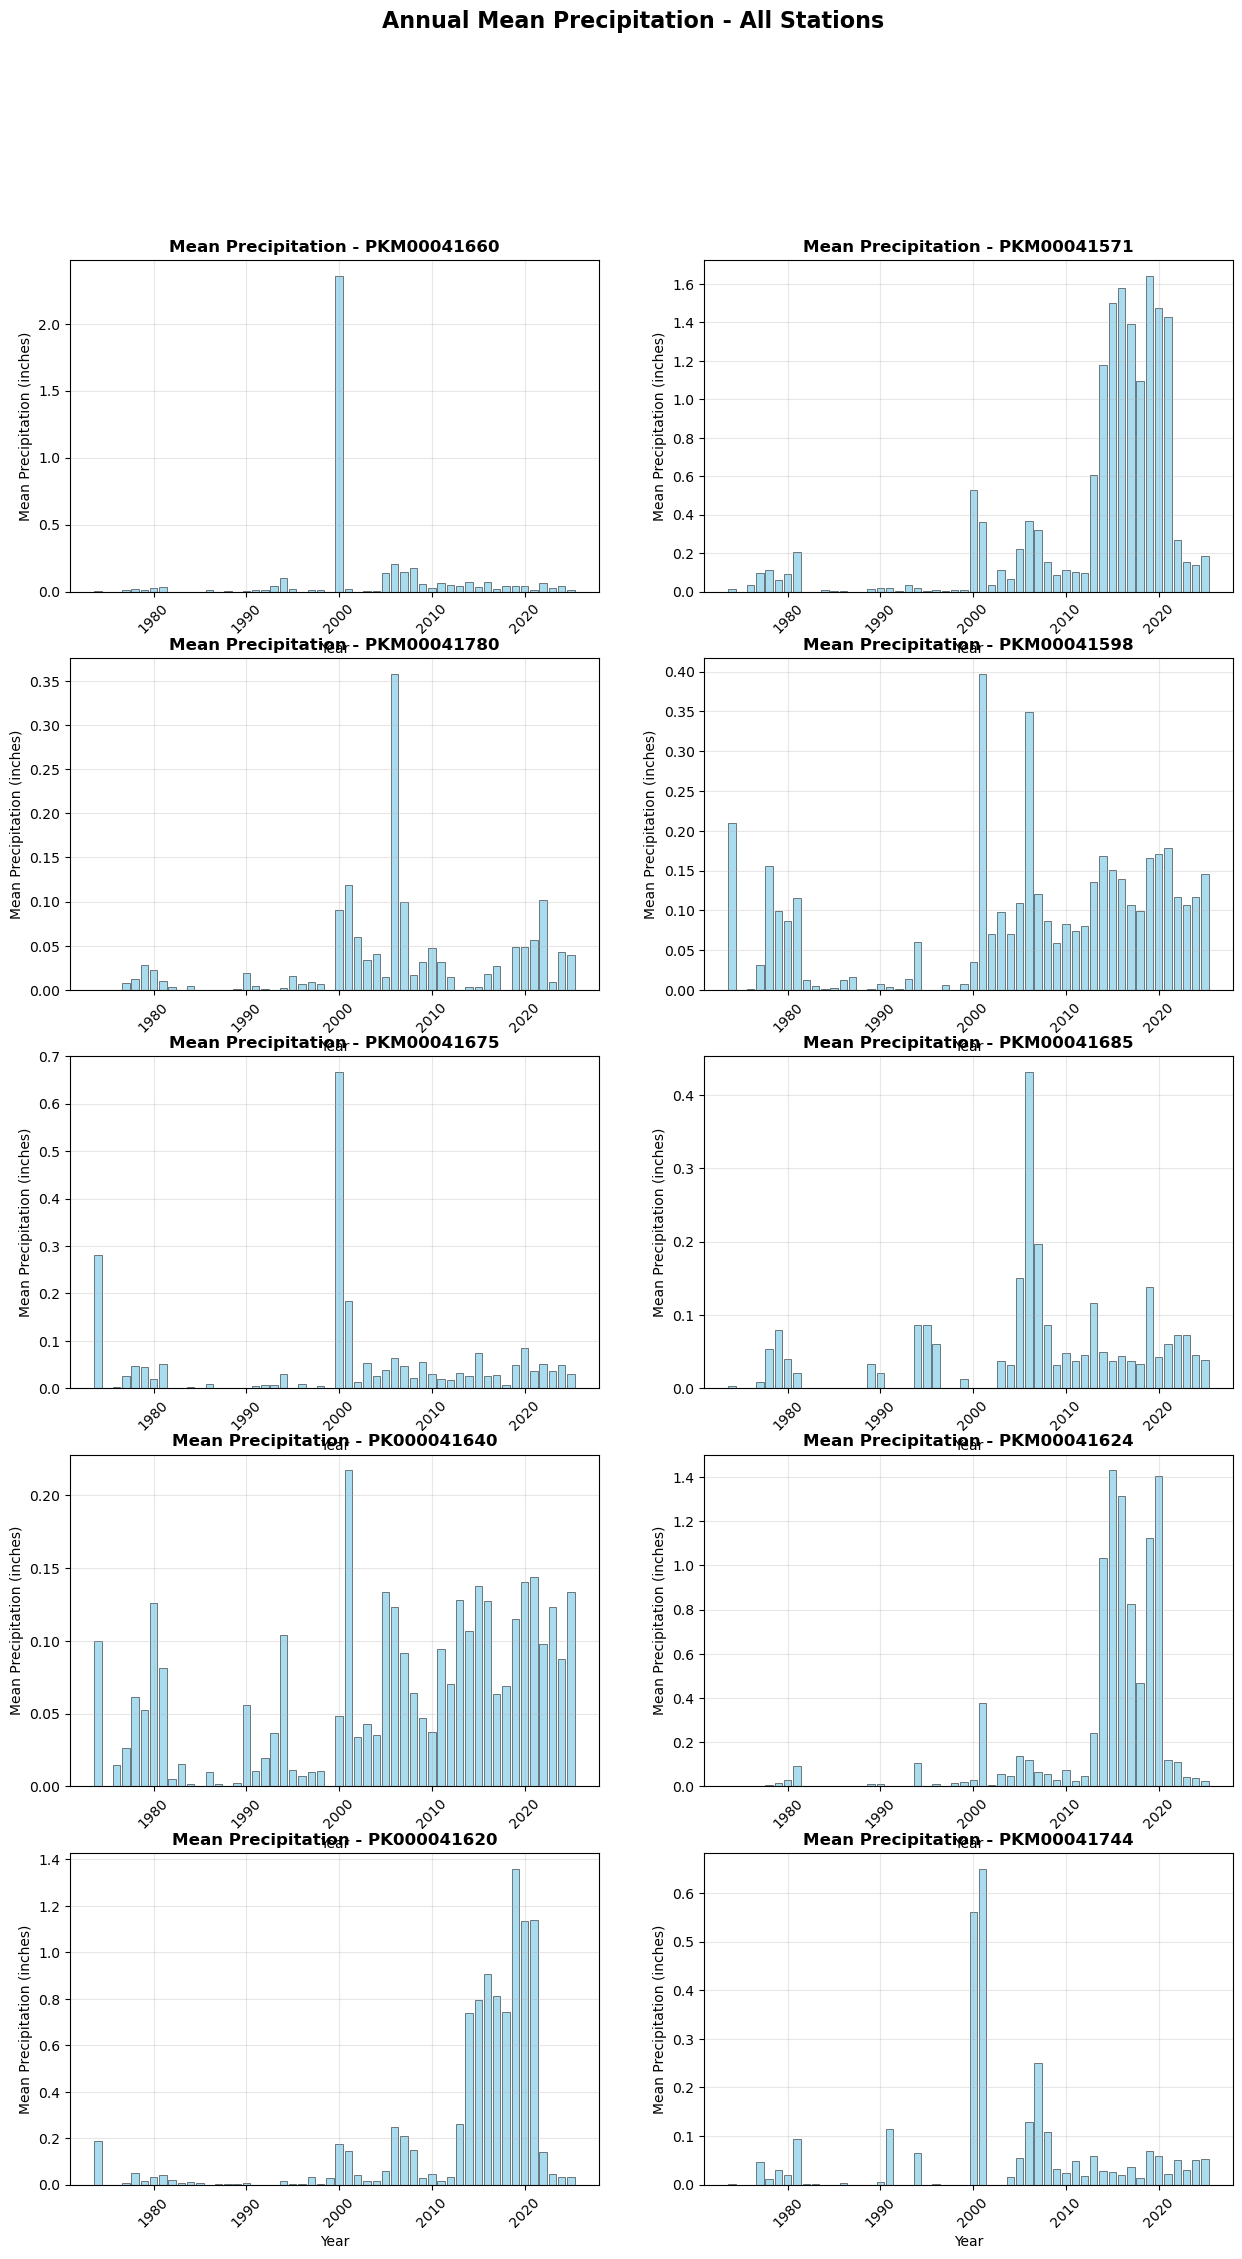

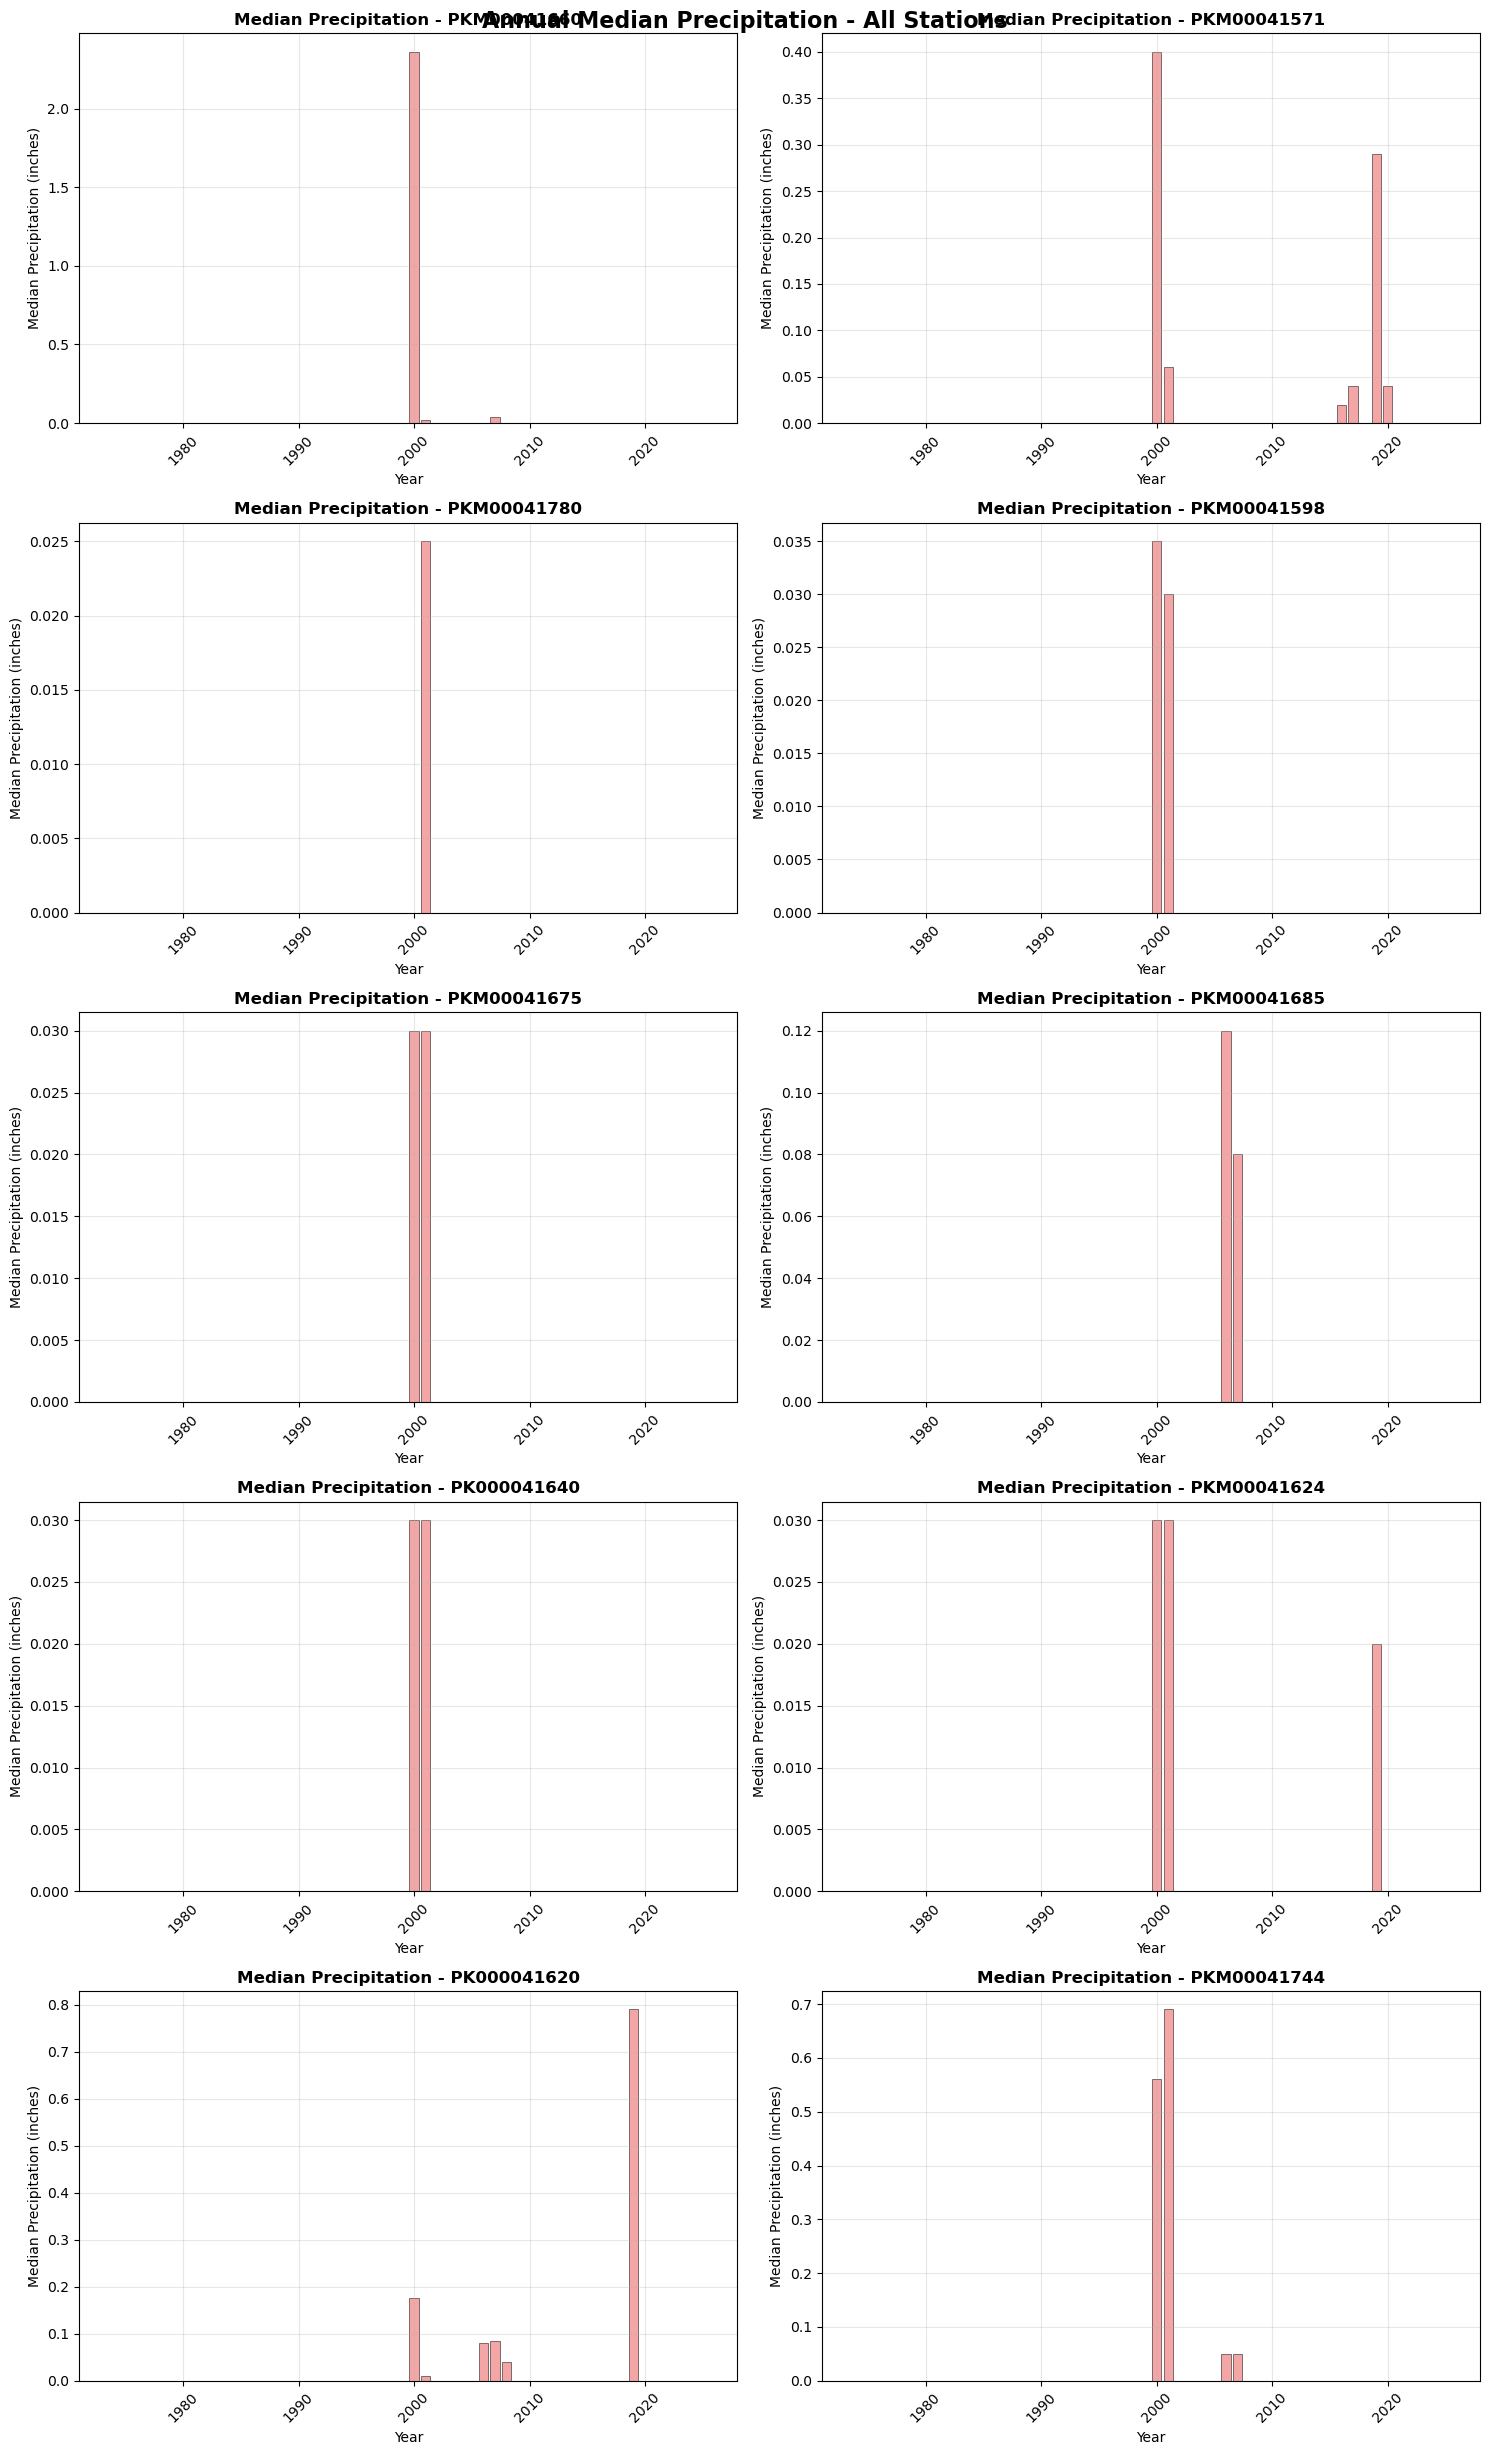

In [11]:
plot_all_stations_facet(annual_percipitation_stats)

Citation:

- How to make trendlines in matplotlib: https://www.statology.org/matplotlib-trendline/

`plot_trendlines_all_stations` is a function that will take the dict with the annual stats and produce a figure with trend lines for the means and medians of different stations.

In [12]:
def plot_trendlines_all_stations(annual_stats_dict: Dict[str, pd.DataFrame]) -> Tuple[plt.Figure, plt.Figure]:
    """
    Create trendline plots for all stations with different colors for each station.
    
    Parameters:
    annual_stats_dict (Dict[str, pd.DataFrame]): Dictionary of annual stats for all stations
    
    Returns:
    Tuple[plt.Figure, plt.Figure]: Mean trendlines figure, Median trendlines figure
    """
    # Set up color palette
    colors = plt.cm.Set1(np.linspace(0, 1, len(annual_stats_dict)))
    
    # Mean trendlines
    fig_mean, ax_mean = plt.subplots(figsize=(12, 8))
    
    for i, (station_id, df) in enumerate(annual_stats_dict.items()):
        ax_mean.plot(df['year'], df['mean_precipitation'], 
                    marker='o', linewidth=2, markersize=4, 
                    color=colors[i], label=f'Station {station_id}', alpha=0.8)
    
    ax_mean.set_title('Annual Mean Precipitation Trends - All Stations', fontsize=14, fontweight='bold')
    ax_mean.set_xlabel('Year', fontsize=12)
    ax_mean.set_ylabel('Mean Precipitation (inches)', fontsize=12)
    ax_mean.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_mean.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Median trendlines
    fig_median, ax_median = plt.subplots(figsize=(12, 8))
    
    for i, (station_id, df) in enumerate(annual_stats_dict.items()):
        ax_median.plot(df['year'], df['median_precipitation'], 
                      marker='s', linewidth=2, markersize=4, 
                      color=colors[i], label=f'Station {station_id}', alpha=0.8)
    
    ax_median.set_title('Annual Median Precipitation Trends - All Stations', fontsize=14, fontweight='bold')
    ax_median.set_xlabel('Year', fontsize=12)
    ax_median.set_ylabel('Median Precipitation (inches)', fontsize=12)
    ax_median.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_median.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig_mean, fig_median

(<Figure size 1200x800 with 1 Axes>, <Figure size 1200x800 with 1 Axes>)

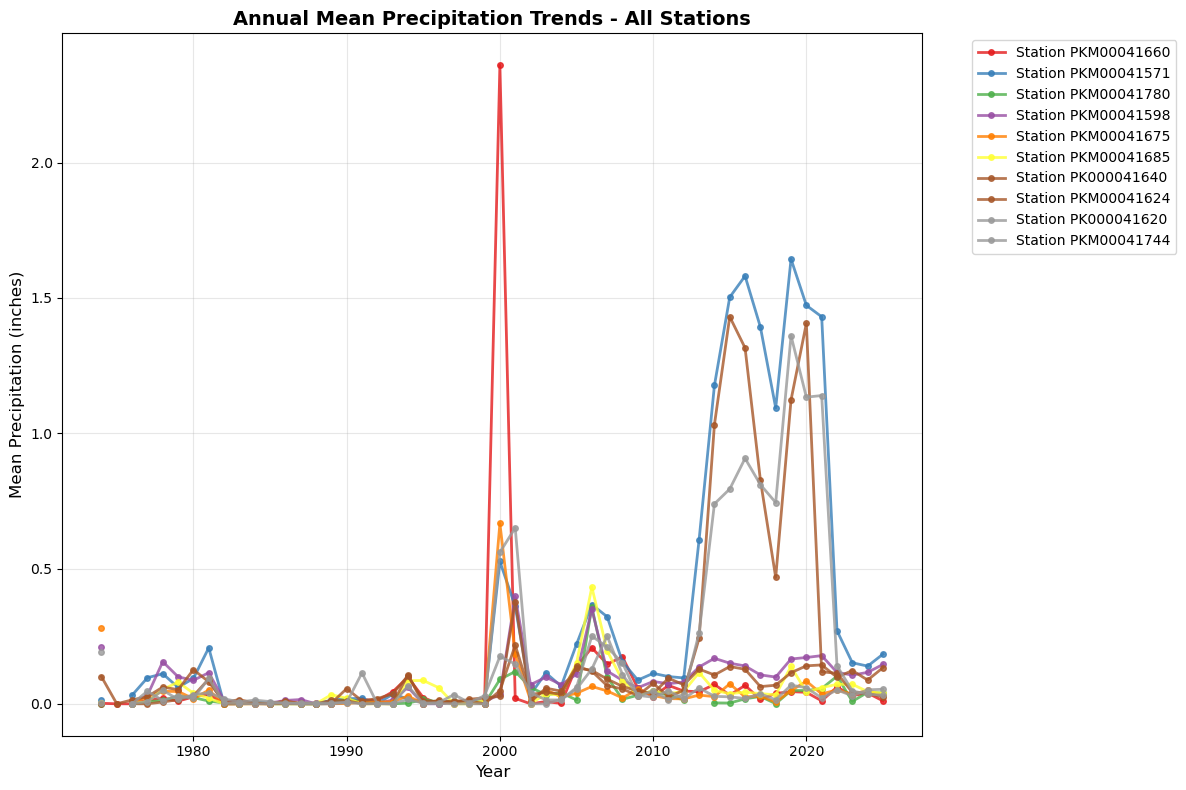

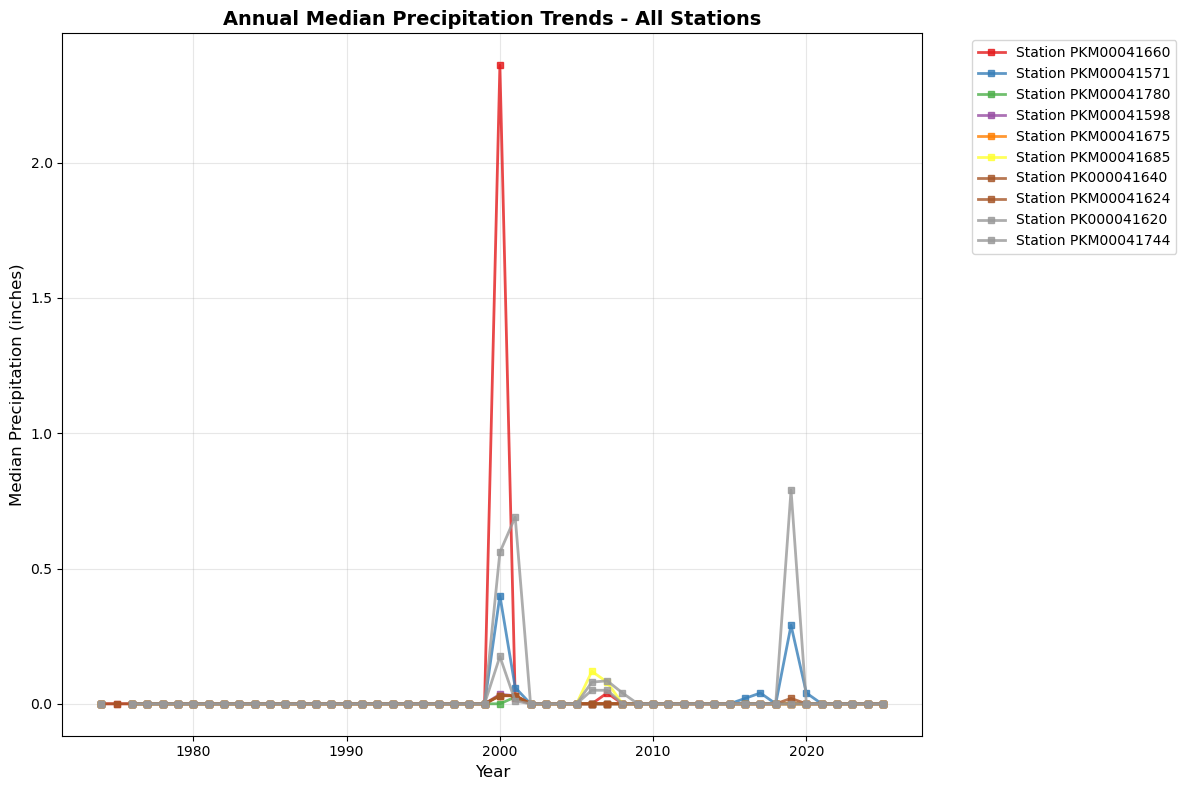

In [13]:
plot_trendlines_all_stations(annual_percipitation_stats)

## Rates of changes across stations?

How are precipitation changes between and across stations? Are they similar or different? Do they ebb and flow in a similar fashion?

To answer this question we will use the function `calculate_pairwise_precip_correlations`.

This function takes the `stations_dataframes` to try generate a pearson statistic and see how tight their ups and downs are.

In [14]:
def calculate_pairwise_precip_correlations(station_dataframes: Dict[str, pd.DataFrame]) -> Dict:
    """
    Calculate pairwise Pearson correlations of annual precipitation
    between stations, using only years common to all stations.

    Parameters:
    station_dataframes (dict): {station_id: DataFrame with 'year' and 'precipitation_original'}

    Returns:
    dict: correlations list + summary stats
    """
    #  Find common years across all stations
    common_years = None
    for df in station_dataframes.values():
        clean_df = df.dropna(subset=['precipitation_original'])
        if len(clean_df) < 10:
            continue
        years = set(clean_df['year'])
        common_years = years if common_years is None else common_years.intersection(years)

    if not common_years:
        return {"correlations": [], "mean": None, "std": None, "min": None, "max": None}

    common_years = sorted(list(common_years))

    #  Build aligned annual series for each station
    annual_precip_by_station = {}
    for station_id, df in station_dataframes.items():
        clean_df = df.dropna(subset=['precipitation_original'])
        if len(clean_df) < 10:
            continue
        annual_df = clean_df.groupby('year')['precipitation_original'].mean().reset_index()
        annual_df = annual_df[annual_df['year'].isin(common_years)].sort_values('year')
        annual_precip_by_station[station_id] = annual_df['precipitation_original'].values

    #  Compute pairwise Pearson correlations
    station_ids = list(annual_precip_by_station.keys())
    correlations = []
    for i in range(len(station_ids)):
        for j in range(i+1, len(station_ids)):
            r, _ = stats.pearsonr(annual_precip_by_station[station_ids[i]],
                                  annual_precip_by_station[station_ids[j]])
            correlations.append(r)

    # Return results
    return {
        "correlations": correlations,
        "mean": np.mean(correlations) if correlations else None,
        "std": np.std(correlations) if correlations else None,
        "min": np.min(correlations) if correlations else None,
        "max": np.max(correlations) if correlations else None
    }


In [15]:
pearsonr_data = calculate_pairwise_precip_correlations(station_dataframes)

How does this look in a plot?

In [16]:

def plot_pairwise_correlations(corr_results: dict):
    """
    Plot histogram of pairwise Pearson correlations between stations.

    Parameters:
    corr_results (dict): Output from calculate_pairwise_precip_correlations()
                         with keys: 'correlations', 'mean', 'std', 'min', 'max'
    """
    correlations = corr_results.get("correlations", [])
    mean_corr = corr_results.get("mean", None)

    fig, ax = plt.subplots(figsize=(8, 6))

    if correlations:
        ax.hist(correlations, bins=min(15, len(correlations)),
                alpha=0.7, color='lightcoral', edgecolor='black')
        if mean_corr is not None:
            ax.axvline(x=mean_corr, color='red', linestyle='--',
                       label=f"Mean: {mean_corr:.3f}")
        ax.set_xlabel("Pairwise Correlation")
        ax.set_ylabel("Frequency")
        ax.set_title("Station-to-Station Correlations")
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No correlation data available',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()

    plt.tight_layout()
    return fig


## Primer on Pearson's R

- r near 1 -> A perfect consistent relationship
- r near 0 -> no consistent relationship
- The spetrum between 0 and 1 indicates the strenght of the similarity.

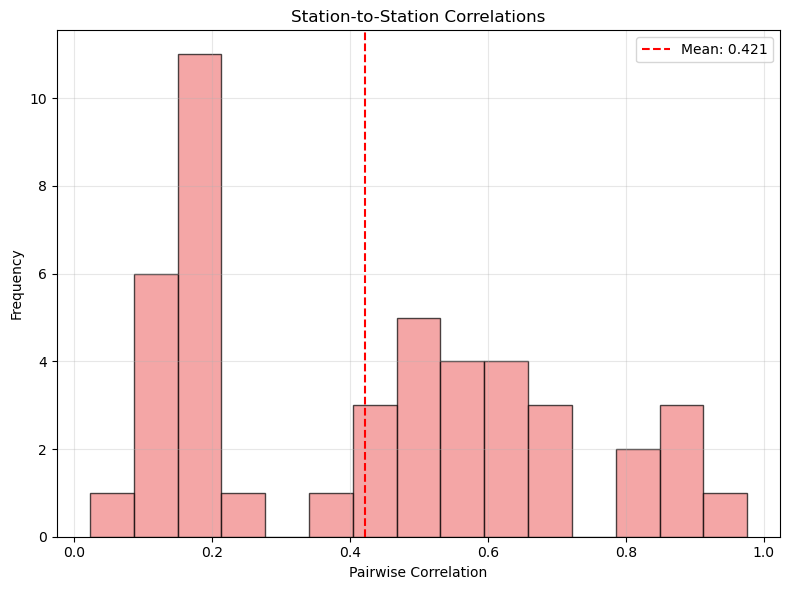

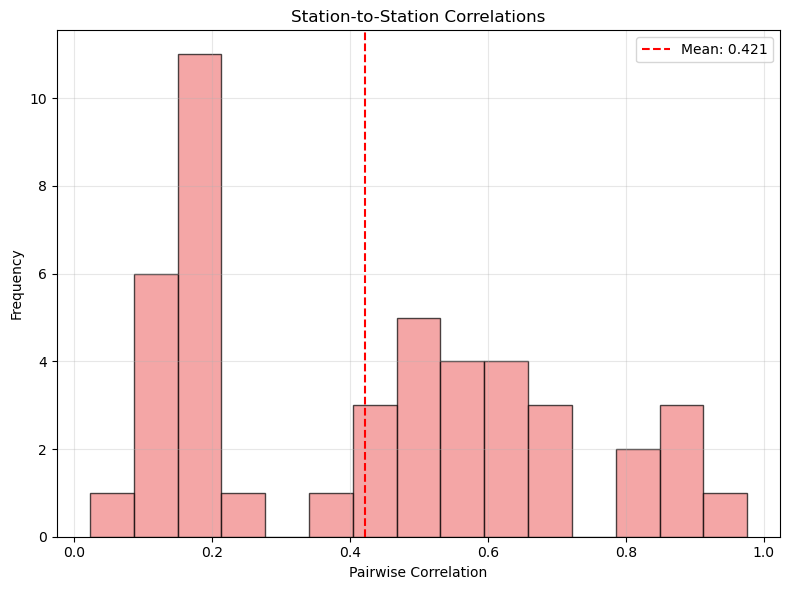

In [17]:
plot_pairwise_correlations(pearsonr_data)

Given that our mean is 0.421 - I think we should say they "somewhat similar".

How do the slopes of the different stations look?

In [18]:
def calculate_slopes(station_dataframes):
    """
    Calculate slope (trend) for each station's precipitation over time.

    Parameters:
    station_dataframes (dict): {station_id: DataFrame with 'year' and 'precipitation_original'}

    Returns:
    dict: {station_id: slope_in_inches_per_year}
    """
    slopes = {}
    for station_id, df in station_dataframes.items():
        clean_df = df.dropna(subset=['precipitation_original'])
        if len(clean_df) < 2:
            continue
        # Linear regression: precipitation vs year
        slope, intercept, r_value, p_value, std_err = linregress(
            clean_df['year'], clean_df['precipitation_original']
        )
        slopes[station_id] = {
            "slope": slope,
            "intercept": intercept,
            "r_value": r_value,
            "p_value": p_value,
            "std_err": std_err
        }
    return slopes

In [19]:
slopes = calculate_slopes(station_dataframes)

In [20]:
def plot_all_station_trendlines(station_dataframes, log_transform=True):
    """
    Plot only the fitted trendlines for each station's precipitation over time.
    
    Parameters:
    station_dataframes (dict): {station_id: DataFrame with 'year' and 'precipitation_original'}
    log_transform (bool): If True, apply log transform to precipitation before fitting.
    """
    plt.figure(figsize=(12, 8))

    for station_id, df in station_dataframes.items():
        clean_df = df.dropna(subset=['precipitation_original'])
        if len(clean_df) < 2:
            continue

        years = clean_df['year'].values
        precip = clean_df['precipitation_original'].values

        # Optional log transform
        if log_transform:
            precip = np.log(precip)

        # Fit slope and intercept
        slope, intercept, r_value, p_value, std_err = linregress(years, precip)

        # Generate smooth line for plotting
        year_range = np.linspace(years.min(), years.max(), 100)
        trendline = intercept + slope * year_range

        # If log-transformed, back-transform for plotting in original units
        if log_transform:
            trendline = np.exp(trendline)

        plt.plot(year_range, trendline, linewidth=2, label=f"{station_id} ({slope:.4f}{' log' if log_transform else ''}/yr)")

    plt.xlabel("Year")
    plt.ylabel("Annual Mean Precipitation" + (" (inches, log scale fit)" if log_transform else " (inches)"))
    plt.title("Trendlines of Annual Mean Precipitation - All Stations")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()

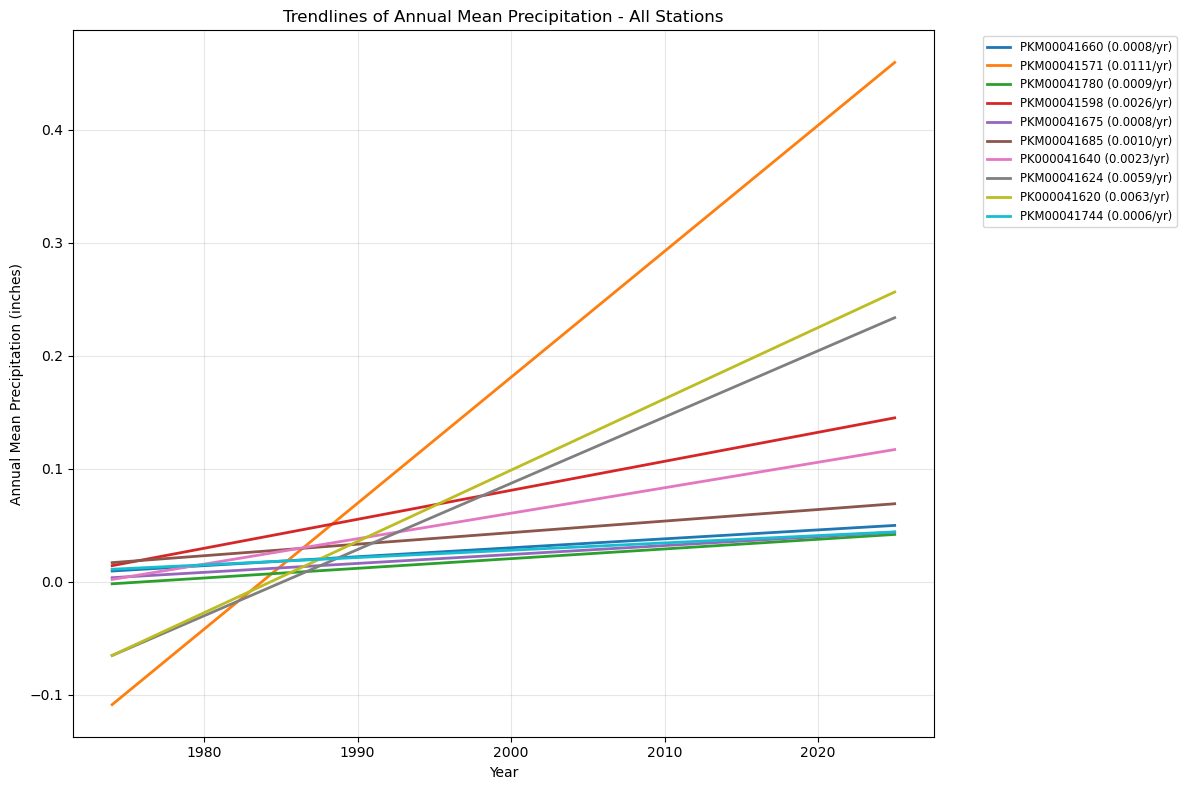

In [21]:
fig = plot_all_station_trendlines(station_dataframes, log_transform=False)
plt.show()

PKM00041571 (the line in orange) is the weather station at Islamabad. This corresponds to the deadly 2021 flooding in Islamabad.